**The Strategy:**

- **Orders (olist_orders_dataset.csv):** The central hub. Contains timestamps and status.

- **Items (olist_order_items_dataset.csv):** Gives us the price and freight value.

- **Products (olist_products_dataset.csv):** Gives us the product category and dimensions.

- **Customers (olist_customers_dataset.csv):** Gives us the geolocation (state, city) of the buyer.

- **Reviews (olist_order_reviews_dataset.csv):** Crucial for your LLM research. Gives us the review score, review title, and the actual Portuguese review message.

In [246]:
import pandas as pd
import os
import numpy as np

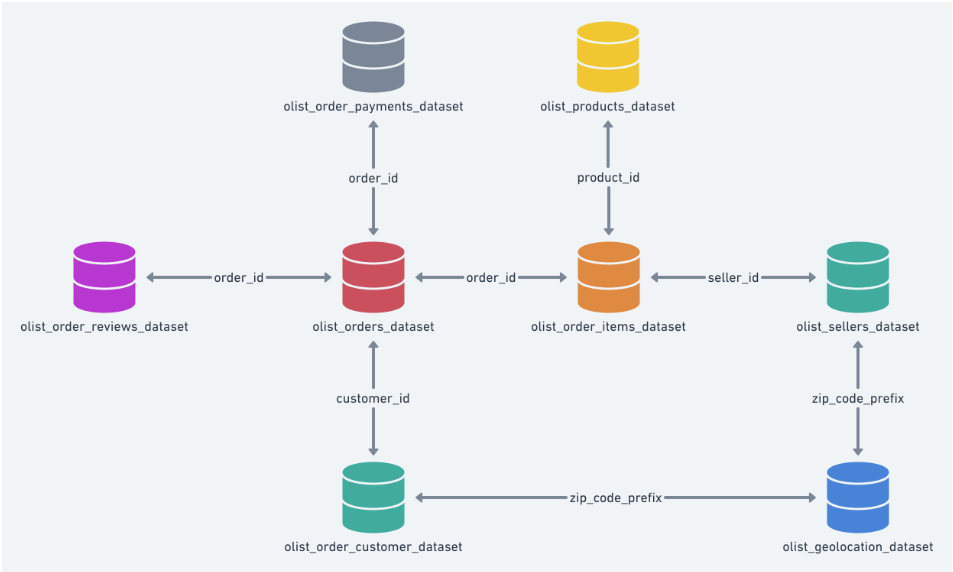

In [247]:
# Define the path to your raw data
data_path = '../data/raw/'

# 1. Load the core datasets
orders = pd.read_csv(os.path.join(data_path, 'olist_orders_dataset.csv'))
items = pd.read_csv(os.path.join(data_path, 'olist_order_items_dataset.csv'))
products = pd.read_csv(os.path.join(data_path, 'olist_products_dataset.csv'))
customers = pd.read_csv(os.path.join(data_path, 'olist_customers_dataset.csv'))
reviews = pd.read_csv(os.path.join(data_path, 'olist_order_reviews_dataset.csv'))

# 2. Execute the joins (Left merges ensure we don't lose the base order data)
# Merge items into orders
df = pd.merge(orders, items, on='order_id', how='left')

# Merge product details
df = pd.merge(df, products, on='product_id', how='left')

# Merge customer details
df = pd.merge(df, customers, on='customer_id', how='left')

# Merge reviews (This brings in the NLP text)
df = pd.merge(df, reviews, on='order_id', how='left')

# 3. Quick check of our combined dataset
print(f"Total Rows: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")

Total Rows: 114092
Total Features: 32


In [248]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,...,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,65266b2da20d04dbe00c5c2d3bb7859e,...,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51


In [249]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114092 entries, 0 to 114091
Data columns (total 32 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       114092 non-null  str    
 1   customer_id                    114092 non-null  str    
 2   order_status                   114092 non-null  str    
 3   order_purchase_timestamp       114092 non-null  str    
 4   order_approved_at              113930 non-null  str    
 5   order_delivered_carrier_date   112112 non-null  str    
 6   order_delivered_customer_date  110839 non-null  str    
 7   order_estimated_delivery_date  114092 non-null  str    
 8   order_item_id                  113314 non-null  float64
 9   product_id                     113314 non-null  str    
 10  seller_id                      113314 non-null  str    
 11  shipping_limit_date            113314 non-null  str    
 12  price                          113314 non

# Convert timestamps to datetime objects

In [250]:
time_cols = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in time_cols:
    df[col] = pd.to_datetime(df[col])

# Calculate actual delivery time in days

In [251]:
df['actual_delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

# Calculate delivery delay (if negative, it arrived early)

In [252]:
df['delivery_delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days

In [253]:
df["delivery_delay_days"].value_counts().sort_index()

delivery_delay_days
-147.0    2
-140.0    1
-135.0    1
-124.0    2
-109.0    1
         ..
 166.0    1
 167.0    1
 175.0    1
 181.0    1
 188.0    1
Name: count, Length: 198, dtype: int64

Data Prep for NLP

- Dropping out those row where the review is not a text. Like a star rating. Which is problematic for nlp model analysis.

In [254]:
print(df.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'actual_delivery_days', 'delivery_delay_days']


In [255]:
# Missing Value Handling
print("Missing Data Percentage Before:")
print((df.isnull().sum() / len(df)) * 100)

Missing Data Percentage Before:
order_id                          0.000000
customer_id                       0.000000
order_status                      0.000000
order_purchase_timestamp          0.000000
order_approved_at                 0.141991
order_delivered_carrier_date      1.735442
order_delivered_customer_date     2.851208
order_estimated_delivery_date     0.000000
order_item_id                     0.681906
product_id                        0.681906
seller_id                         0.681906
shipping_limit_date               0.681906
price                             0.681906
freight_value                     0.681906
product_category_name             2.094801
product_name_lenght               2.094801
product_description_lenght        2.094801
product_photos_qty                2.094801
product_weight_g                  0.697683
product_length_cm                 0.697683
product_height_cm                 0.697683
product_width_cm                  0.697683
customer_unique_id    

In [256]:
# Filter out rows where the user left a star rating but NO text review body.
# We are dropping rows where 'review_comment_message' is NaN.
df_nlp = df.dropna(subset=['review_comment_message']) 

print(f"Total Rows with Text Reviews: {df_nlp.shape[0]}")

Total Rows with Text Reviews: 48166


# Capping Actual_delivery_days and delivery_delay_days TO get rid off Extreme values

In [257]:
# Drop outliers in delivery_delay_days using the already computed IQR bounds
# Reusable function to calculate bounds and remove outliers
def calculate_and_remove_outliers(dataframe, columns):
    df_clean = dataframe.copy()
    bounds_dict = {}
    
    print("=" * 80)
    print("OUTLIER BOUNDS CALCULATION (IQR Method)")
    print("=" * 80)
    
    for column in columns:
        Q1 = df_clean[column].quantile(0.25)
        Q3 = df_clean[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        bounds_dict[column] = {'lower': lower_bound, 'upper': upper_bound, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR}
        
        print(f"\n{column.upper()}:")
        print(f"  Q1 (25th percentile): {Q1:.2f}")
        print(f"  Q3 (75th percentile): {Q3:.2f}")
        print(f"  IQR: {IQR:.2f}")
        print(f"  Lower Bound (Q1 - 1.5×IQR): {lower_bound:.2f}")
        print(f"  Upper Bound (Q3 + 1.5×IQR): {upper_bound:.2f}")
    
    print("\n" + "=" * 80)
    print("REMOVING OUTLIER ROWS")
    print("=" * 80)
    
    for column in columns:
        rows_before = len(df_clean)
        lower = bounds_dict[column]['lower']
        upper = bounds_dict[column]['upper']
        
        # Keep rows where value is within bounds or NaN
        df_clean = df_clean[(df_clean[column].isna()) | 
                           ((df_clean[column] >= lower) & (df_clean[column] <= upper))]
        
        rows_removed = rows_before - len(df_clean)
        print(f"\n{column}:")
        print(f"  Rows before: {rows_before}")
        print(f"  Rows removed: {rows_removed}")
        print(f"  Rows after: {len(df_clean)}")
    
    return df_clean, bounds_dict

# Apply outlier removal
print("\nBefore removal: {0} rows, {1} columns".format(df_nlp.shape[0], df_nlp.shape[1]))
print("\nStatistics BEFORE removing outliers:")
display(df_nlp[[ 'actual_delivery_days', 'delivery_delay_days']].describe().T)

df_nlp, bounds = calculate_and_remove_outliers(df_nlp, [ 'actual_delivery_days', 'delivery_delay_days'])

print(f"\n\nAfter removal: {df_nlp.shape[0]} rows, {df_nlp.shape[1]} columns")
print("\nStatistics AFTER removing outliers:")
display(df_nlp[[ 'actual_delivery_days', 'delivery_delay_days']].describe().T)


Before removal: 48166 rows, 34 columns

Statistics BEFORE removing outliers:


,count,mean,std,min,25%,50%,75%,max
actual_delivery_days,46137.0,12.833994,10.598224,0.0,6.0,10.0,16.0,195.0
delivery_delay_days,46137.0,-11.700436,11.248225,-135.0,-17.0,-13.0,-7.0,175.0


OUTLIER BOUNDS CALCULATION (IQR Method)

ACTUAL_DELIVERY_DAYS:
  Q1 (25th percentile): 6.00
  Q3 (75th percentile): 16.00
  IQR: 10.00
  Lower Bound (Q1 - 1.5×IQR): -9.00
  Upper Bound (Q3 + 1.5×IQR): 31.00

DELIVERY_DELAY_DAYS:
  Q1 (25th percentile): -17.00
  Q3 (75th percentile): -7.00
  IQR: 10.00
  Lower Bound (Q1 - 1.5×IQR): -32.00
  Upper Bound (Q3 + 1.5×IQR): 8.00

REMOVING OUTLIER ROWS

actual_delivery_days:
  Rows before: 48166
  Rows removed: 2545
  Rows after: 45621

delivery_delay_days:
  Rows before: 45621
  Rows removed: 1259
  Rows after: 44362


After removal: 44362 rows, 34 columns

Statistics AFTER removing outliers:


,count,mean,std,min,25%,50%,75%,max
actual_delivery_days,42333.0,10.957645,6.511365,0.0,6.0,10.0,15.0,31.0
delivery_delay_days,42333.0,-12.672761,7.337492,-32.0,-17.0,-13.0,-8.0,8.0


In [258]:
# High freight costs or extreme prices can skew our regression models later.
def cap_outliers(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR
    # Cap values at the 95th percentile data instead of dropping them, preserving the row
    dataframe[column] = np.where(dataframe[column] > upper_bound, dataframe[column].quantile(0.95), dataframe[column])
    # Cap values at the 5th percentile data instead of dropping them, preserving the row
    dataframe[column] = np.where(dataframe[column] < lower_bound, dataframe[column].quantile(0.05), dataframe[column])
    
    return dataframe

print("Price and Freight Value Statistics Before Capping:")
display(df_nlp[[ 'price', 'freight_value']].describe().T)

df_nlp = cap_outliers(df_nlp, 'price')
df_nlp = cap_outliers(df_nlp, 'freight_value')

print("Price and Freight Value Statistics After Capping:")
display(df_nlp[[ 'price', 'freight_value']].describe().T)


Price and Freight Value Statistics Before Capping:


,count,mean,std,min,25%,50%,75%,max
price,43838.0,122.799671,189.104157,0.85,39.99,75.00,135.00,6735.00
freight_value,43838.0,20.133877,16.216935,0.00,12.97,16.26,21.28,375.28


Price and Freight Value Statistics After Capping:


,count,mean,std,min,25%,50%,75%,max
price,43838.0,105.192825,92.079850,0.85,39.99,75.00,135.00,358.00
freight_value,43838.0,19.207043,10.593893,0.61,12.97,16.26,21.28,46.05


In [259]:
# Clean the Portuguese text by lowering case and removing basic special characters
df_nlp['clean_review'] = df_nlp['review_comment_message'].str.lower()
df_nlp['clean_review'] = df_nlp['clean_review'].str.replace(r'[^\w\s]', '', regex=True)
df_nlp['review_length_words'] = df_nlp['clean_review'].apply(lambda x: len(str(x).split()))

In [260]:
# Missing Value Handling
print("Missing Data Percentage Before:")
print((df_nlp.isnull().sum() / len(df)) * 100)

Missing Data Percentage Before:
order_id                          0.000000
customer_id                       0.000000
order_status                      0.000000
order_purchase_timestamp          0.000000
order_approved_at                 0.089402
order_delivered_carrier_date      1.149949
order_delivered_customer_date     1.778389
order_estimated_delivery_date     0.000000
order_item_id                     0.459278
product_id                        0.459278
seller_id                         0.459278
shipping_limit_date               0.459278
price                             0.459278
freight_value                     0.459278
product_category_name             1.034253
product_name_lenght               1.034253
product_description_lenght        1.034253
product_photos_qty                1.034253
product_weight_g                  0.470673
product_length_cm                 0.470673
product_height_cm                 0.470673
product_width_cm                  0.470673
customer_unique_id    

In [261]:
df_nlp.info()

<class 'pandas.DataFrame'>
Index: 44362 entries, 0 to 114090
Data columns (total 36 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       44362 non-null  str           
 1   customer_id                    44362 non-null  str           
 2   order_status                   44362 non-null  str           
 3   order_purchase_timestamp       44362 non-null  datetime64[us]
 4   order_approved_at              44260 non-null  str           
 5   order_delivered_carrier_date   43050 non-null  str           
 6   order_delivered_customer_date  42333 non-null  datetime64[us]
 7   order_estimated_delivery_date  44362 non-null  datetime64[us]
 8   order_item_id                  43838 non-null  float64       
 9   product_id                     43838 non-null  str           
 10  seller_id                      43838 non-null  str           
 11  shipping_limit_date           

In [262]:
#finding duplicate values
df_nlp.duplicated().sum()

np.int64(0)

In [263]:
# Garbage values can be inconsistent spellings, extra spaces, symbols, or unexpected categories
for i in df.select_dtypes(include="object").columns:
    print(df[i].value_counts())
    print("***"*15)

order_id
5a3b1c29a49756e75f1ef513383c0c12    22
8272b63d03f5f79c56e9e4120aec44ef    21
1b15974a0141d54e36626dca3fdc731a    20
ab14fdcfbe524636d65ee38360e22ce8    20
428a2f660dc84138d969ccd69a0ab6d5    15
                                    ..
880675dff2150932f1601e1c07eadeeb     1
9c5dedf39a927c1b2549525ed64a053c     1
63943bddc261676b46f01ca7ac2f7bd8     1
83c1379a015df1e13d02aae0204711ab     1
66dea50a8b16d9b4dee7af250b4be1a5     1
Name: count, Length: 99441, dtype: int64
*********************************************
customer_id
be1c4e52bb71e0c54b11a26b8e8d59f2    22
fc3d1daec319d62d49bfb5e1f83123e9    21
be1b70680b9f9694d8c70f41fa3dc92b    20
bd5d39761aa56689a265d95d8d32b8be    20
10de381f8a8d23fff822753305f71cae    15
                                    ..
47cd45a6ac7b9fb16537df2ccffeb5ac     1
39bd1228ee8140590ac3aca26f2dfe00     1
1fca14ff2861355f6e5f14306ff977a7     1
1aa71eb042121263aafbe80c1b562c9c     1
edb027a75a1449115f6b43211ae02a24     1
Name: count, Length: 99441, dtype:

C:\Users\User\AppData\Local\Temp\ipykernel_14840\274660922.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for i in df.select_dtypes(include="object").columns:


order_delivered_carrier_date
2018-05-09 15:48:00    48
2018-05-10 18:29:00    36
2017-10-20 19:09:07    22
2018-08-08 15:01:00    21
2018-05-07 12:31:00    21
                       ..
2017-03-01 10:22:52     1
2017-03-10 11:18:03     1
2018-02-07 23:22:42     1
2017-08-28 20:52:26     1
2018-03-09 22:11:59     1
Name: count, Length: 81018, dtype: int64
*********************************************
product_id
aca2eb7d00ea1a7b8ebd4e68314663af    527
99a4788cb24856965c36a24e339b6058    491
422879e10f46682990de24d770e7f83d    487
389d119b48cf3043d311335e499d9c6b    392
368c6c730842d78016ad823897a372db    391
                                   ... 
af87aa3f5f2c05c8c4db6bee2088672b      1
cbaf5898b92064cd5e399c7cff291d0a      1
3d2c44374ee42b3003a470f3e937a2ea      1
ac35486adb7b02598c182c2ff2e05254      1
006619bbed68b000c8ba3f8725d5409e      1
Name: count, Length: 32951, dtype: int64
*********************************************
seller_id
6560211a19b47992c3666cc44a7e94c0    2039
4a3ca9315

In [272]:
df_nlp.info()

<class 'pandas.DataFrame'>
Index: 44362 entries, 0 to 114090
Data columns (total 36 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       44362 non-null  str           
 1   customer_id                    44362 non-null  str           
 2   order_status                   44362 non-null  str           
 3   order_purchase_timestamp       44362 non-null  datetime64[us]
 4   order_approved_at              44260 non-null  str           
 5   order_delivered_carrier_date   43050 non-null  str           
 6   order_delivered_customer_date  42333 non-null  datetime64[us]
 7   order_estimated_delivery_date  44362 non-null  datetime64[us]
 8   order_item_id                  43838 non-null  float64       
 9   product_id                     43838 non-null  str           
 10  seller_id                      43838 non-null  str           
 11  shipping_limit_date           

In [264]:
# After cleaning, we can save the cleaned dataset for future use
df_nlp.to_csv('../data/processed/olist_nlp_dataset.csv', index=False)

Data Prep for ML

In [265]:
# Remove all columns with 'review' in the name
review_cols = [col for col in df.columns if 'review' in col.lower()]
print(f"Columns to remove: {review_cols}")

df_ml = df.drop(columns=review_cols)

print(f"\nRemaining features: {df_ml.shape[1]}")
print(f"Remaining columns: {df_ml.columns.tolist()}")

Columns to remove: ['review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

Remaining features: 28
Remaining columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'actual_delivery_days', 'delivery_delay_days']


In [266]:
df_ml.isnull().sum()


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 162
order_delivered_carrier_date     1980
order_delivered_customer_date    3253
order_estimated_delivery_date       0
order_item_id                     778
product_id                        778
seller_id                         778
shipping_limit_date               778
price                             778
freight_value                     778
product_category_name            2390
product_name_lenght              2390
product_description_lenght       2390
product_photos_qty               2390
product_weight_g                  796
product_length_cm                 796
product_height_cm                 796
product_width_cm                  796
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
actual_deliv

In [267]:
df_ml = df_ml.dropna()
df_ml.isnull().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
order_item_id                    0
product_id                       0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
product_category_name            0
product_name_lenght              0
product_description_lenght       0
product_photos_qty               0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
customer_unique_id               0
customer_zip_code_prefix         0
customer_city                    0
customer_state                   0
actual_delivery_days             0
delivery_delay_days              0
dtype: int64

In [268]:
# Apply outlier removal
print("\nBefore removal: {0} rows, {1} columns".format(df_ml.shape[0], df_ml.shape[1]))
print("\nStatistics BEFORE removing outliers:")
display(df_ml[['price', 'freight_value', 'actual_delivery_days', 'delivery_delay_days']].describe().T)

df_ml, bounds = calculate_and_remove_outliers(df_ml, ['price', 'freight_value', 'actual_delivery_days', 'delivery_delay_days'])

print(f"\n\nAfter removal: {df_ml.shape[0]} rows, {df_ml.shape[1]} columns")
print("\nStatistics AFTER removing outliers:")
display(df_ml[['price', 'freight_value', 'actual_delivery_days', 'delivery_delay_days']].describe().T)


Before removal: 109278 rows, 28 columns

Statistics BEFORE removing outliers:


,count,mean,std,min,25%,50%,75%,max
price,109278.0,119.914910,181.695846,0.85,39.90,74.90,134.00,6735.00
freight_value,109278.0,19.970604,15.708829,0.00,13.08,16.28,21.15,409.68
actual_delivery_days,109278.0,12.007705,9.434533,0.00,6.00,10.00,15.00,209.00
delivery_delay_days,109278.0,-12.043165,10.154682,-147.00,-17.00,-13.00,-7.00,188.00


OUTLIER BOUNDS CALCULATION (IQR Method)

PRICE:
  Q1 (25th percentile): 39.90
  Q3 (75th percentile): 134.00
  IQR: 94.10
  Lower Bound (Q1 - 1.5×IQR): -101.25
  Upper Bound (Q3 + 1.5×IQR): 275.15

FREIGHT_VALUE:
  Q1 (25th percentile): 13.08
  Q3 (75th percentile): 21.15
  IQR: 8.07
  Lower Bound (Q1 - 1.5×IQR): 0.98
  Upper Bound (Q3 + 1.5×IQR): 33.25

ACTUAL_DELIVERY_DAYS:
  Q1 (25th percentile): 6.00
  Q3 (75th percentile): 15.00
  IQR: 9.00
  Lower Bound (Q1 - 1.5×IQR): -7.50
  Upper Bound (Q3 + 1.5×IQR): 28.50

DELIVERY_DELAY_DAYS:
  Q1 (25th percentile): -17.00
  Q3 (75th percentile): -7.00
  IQR: 10.00
  Lower Bound (Q1 - 1.5×IQR): -32.00
  Upper Bound (Q3 + 1.5×IQR): 8.00

REMOVING OUTLIER ROWS

price:
  Rows before: 109278
  Rows removed: 8104
  Rows after: 101174

freight_value:
  Rows before: 101174
  Rows removed: 8882
  Rows after: 92292

actual_delivery_days:
  Rows before: 92292
  Rows removed: 3967
  Rows after: 88325

delivery_delay_days:
  Rows before: 88325
  Rows r

,count,mean,std,min,25%,50%,75%,max
price,86529.0,79.015671,55.806266,0.85,35.64,60.00,109.89,275.00
freight_value,86529.0,15.720173,5.321424,0.98,12.48,15.25,18.32,33.25
actual_delivery_days,86529.0,10.157843,5.916592,0.00,6.00,9.00,14.00,28.00
delivery_delay_days,86529.0,-12.508292,6.912847,-32.00,-17.00,-13.00,-8.00,8.00


In [269]:
# After cleaning, we can save the cleaned dataset for future use
df_ml.to_csv('../data/processed/olist_ml_dataset.csv', index=False)